https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020

UID: unique identifier ranging from 1 to 10000
product ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number
type: just the product type L, M or H from column 2
air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
rotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise
torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.
tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.
a 'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [65]:
df_AI4I = pd.read_csv('datasets/AI4I/cleaned_data.csv')

In [66]:
df_AI4I = df_AI4I.rename(columns={'Product ID' : 'prod_id', 'Air temperature [K]' : 'air_temperature',
       'Process temperature [K]': 'process_temperature', 'Rotational speed [rpm]' : 'rotational_speed', 'Torque [Nm]' : 'torque',
       'Tool wear [min]' : 'tool_wear', 'Machine failure' : 'machine_failure'})

In [76]:
print(f"AI4I:")
print(f"--------------------------------")
print(f"Shape: {df_AI4I.shape}\n")
print(f"Columns: {df_AI4I.columns}\n")
print(f"Count: {df_AI4I['machine_failure'].value_counts()}\n")
print(f"Products: {df_AI4I['prod_id'].unique()}\n")
print(f"Unique per column: {df_AI4I.nunique()}\n")
print(f"Max-Min values")
print(f"Air Temperature [K]: max: {df_AI4I.air_temperature.max()}, min: {df_AI4I.air_temperature.min()}")
print(f"Process temperature [K]: max: {df_AI4I.process_temperature.max()}, min: {df_AI4I.process_temperature.min()}")
print(f"Rotational speed [rpm]: max: {df_AI4I.rotational_speed.max()}, min: {df_AI4I.rotational_speed.min()}")
print(f"Torque [Nm]: max: {df_AI4I.torque.max()}, min: {df_AI4I.torque.min()}")
print(f"Tool wear [min]: max: {df_AI4I.tool_wear.max()}, min: {df_AI4I.tool_wear.min()}\n")
df_error = df_AI4I[df_AI4I['machine_failure'] == 1]
print(f"Max-Min values where there is an error")
print(f"Air Temperature [K]: max: {df_error.air_temperature.max()}, min: {df_error.air_temperature.min()}")
print(f"Process temperature [K]: max: {df_error.process_temperature.max()}, min: {df_error.process_temperature.min()}")
print(f"Rotational speed [rpm]: max: {df_error.rotational_speed.max()}, min: {df_error.rotational_speed.min()}")
print(f"Torque [Nm]: max: {df_error.torque.max()}, min: {df_error.torque.min()}")
print(f"Tool wear [min]: max: {df_error.tool_wear.max()}, min: {df_error.tool_wear.min()}\n")

print(f"Original Headers / Units: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm]',Tool wear [min], Machine failure\n")

AI4I:
--------------------------------
Shape: (10000, 14)

Columns: Index(['UDI', 'prod_id', 'Type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

Count: machine_failure
0    9661
1     339
Name: count, dtype: int64

Products: ['M14860' 'L47181' 'L47182' ... 'M24857' 'H39412' 'M24859']

Unique per column: UDI                    10000
prod_id                10000
Type                       3
air_temperature           93
process_temperature       82
rotational_speed         668
torque                   528
tool_wear                246
machine_failure            2
TWF                        2
HDF                        2
PWF                        2
OSF                        2
RNF                        2
dtype: int64

Max-Min values
Air Temperature [K]: max: 304.5, min: 295.3
Process temperature [K]: max: 313.8, min: 305.7
Rotational speed [rpm]: max: 1895.5

In [68]:
df_error

,UDI,prod_id,Type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,1895.5,12.8,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410.0,65.7,191,1,0,0,1,1,0
77,78,L47257,L,298.8,308.9,1455.0,41.3,208,1,1,0,0,0,0
160,161,L47340,L,298.4,308.2,1282.0,60.7,216,1,0,0,0,1,0
161,162,L47341,L,298.3,308.1,1412.0,52.3,218,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9758,9759,L56938,L,298.6,309.8,1895.5,16.2,218,1,1,0,0,0,0
9764,9765,L56944,L,298.5,309.5,1294.0,66.7,12,1,0,0,1,0,0
9822,9823,L57002,L,298.5,309.4,1360.0,60.9,187,1,0,0,0,1,0
9830,9831,L57010,L,298.3,309.3,1337.0,56.1,206,1,0,0,0,1,0


In [ ]:
df_AI4I.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Date
0,1970-01-01 00:00:00.000000001,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,1970-01-01
1,1970-01-01 00:00:00.000000002,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,1970-01-01
2,1970-01-01 00:00:00.000000003,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,1970-01-01
3,1970-01-01 00:00:00.000000004,L47183,L,298.2,308.6,1433.0,39.5,7,0,0,0,0,0,0,1970-01-01
4,1970-01-01 00:00:00.000000005,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,1970-01-01


C:\Users\VRODAU\AppData\Local\Temp\ipykernel_6464\3168613885.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')


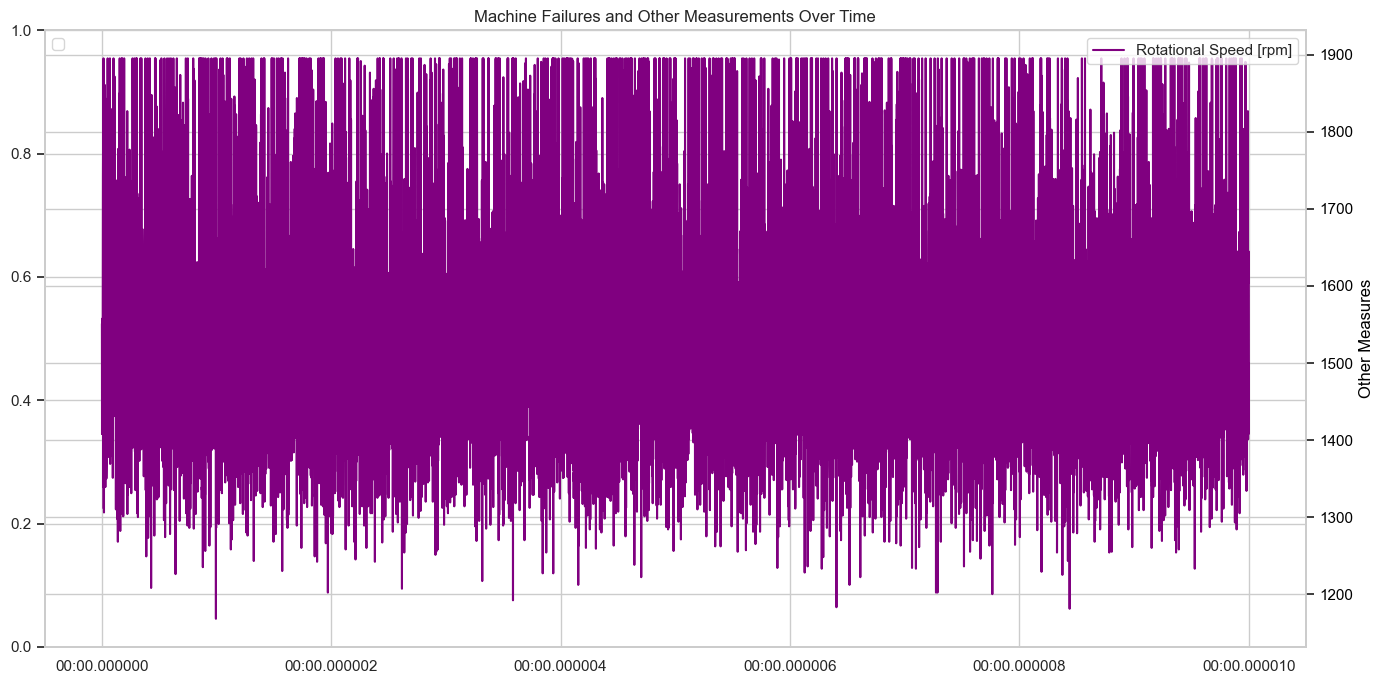

In [ ]:
df_AI4I['UDI'] = pd.to_datetime(df_AI4I['UDI'])

fig, ax1 = plt.subplots(figsize=(14, 7))

#sns.barplot(x=df_AI4I['UDI'], y=df_AI4I['Machine failure'], color='red', ax=ax1, label='Machine Failure', alpha=0.6)
#ax1.set_xlabel('Time')
#ax1.set_ylabel('Machine Failure', color='red')
#ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()

#sns.lineplot(x=df_AI4I['UDI'], y=df_AI4I['Air temperature [K]'], ax=ax2, label='Air Temperature [K]', color='blue')
#sns.lineplot(x=df_AI4I['UDI'], y=df_AI4I['Process temperature [K]'], ax=ax2, label='Process Temperature [K]', color='green')
sns.lineplot(x=df_AI4I['UDI'], y=df_AI4I['Rotational speed [rpm]'], ax=ax2, label='Rotational Speed [rpm]', color='purple')

ax2.set_ylabel('Other Measures', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.xticks(rotation=30)

plt.title('Machine Failures and Other Measurements Over Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()
